# Neural Networks: Perceptrons and Network Architecture

## Learning Objectives

1. **Define** a perceptron: $\hat{y} = \text{sgn}\!\left(\sum_i w_i x_i + b\right)$
2. **Explain** why single-layer perceptrons cannot solve XOR — motivating hidden layers
3. **Describe** the layers of a feedforward network (input, hidden, output) and the forward-pass computation
4. **Distinguish** fully connected, convolutional, and pooling layer types
5. **Identify** the four key design decisions: depth, width, activation function, and output unit type
6. **Implement** a perceptron and a two-layer MLP from scratch using NumPy


## Problem Statement

### The Perceptron (Rosenblatt, 1958)

A **perceptron** takes $n$ real-valued inputs $x_1, \ldots, x_n$, computes a weighted sum plus bias, and thresholds the result:
$$\hat{y} = \text{sgn}\!\left(\mathbf{w} \cdot \mathbf{x} + b\right) = \text{sgn}\!\left(\sum_{i=1}^n w_i x_i + b\right)$$

The perceptron can classify any **linearly separable** dataset correctly (Perceptron Convergence Theorem). However, it fails on XOR: $\{(0,0)\!\to\!0,\,(1,0)\!\to\!1,\,(0,1)\!\to\!1,\,(1,1)\!\to\!0\}$ — no single hyperplane separates the classes.

### Multi-Layer Feedforward Network

Stacking perceptrons in layers and replacing the hard threshold with a smooth **activation function** $\sigma$ yields a multi-layer neural network:

$$h^{(0)} = \mathbf{x} \quad\text{(input layer)}$$
$$a^{(l)} = W^{(l)} h^{(l-1)} + \mathbf{b}^{(l)} \quad\text{(pre-activation)}$$
$$h^{(l)} = \sigma\!\left(a^{(l)}\right) \quad\text{(hidden layer } l\text{)}$$
$$\hat{\mathbf{y}} = g\!\left(a^{(L)}\right) \quad\text{(output layer with activation } g\text{)}$$

The **Universal Approximation Theorem** guarantees that a single hidden layer with enough units can approximate any continuous function — but depth is often far more efficient than width.


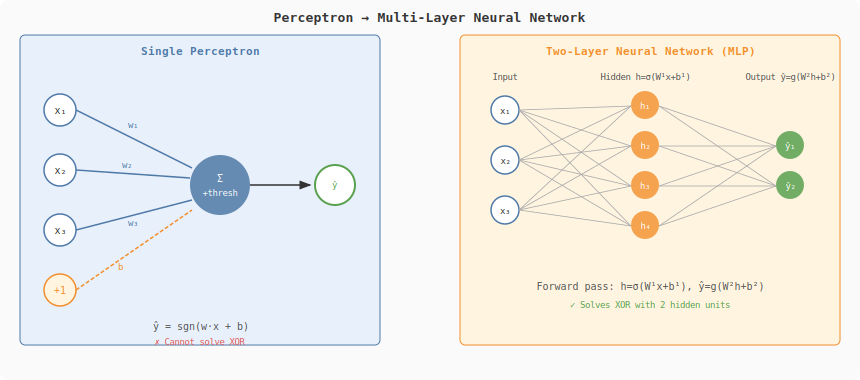

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="860" height="380" font-family="monospace" font-size="12">
  <rect width="860" height="380" fill="#fafafa" rx="8"/>
  <text x="430" y="22" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Perceptron → Multi-Layer Neural Network</text>

  <!-- ── LEFT: single perceptron ── -->
  <rect x="20" y="35" width="360" height="310" rx="5" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="200" y="55" text-anchor="middle" fill="#4e79a7" font-size="11" font-weight="bold">Single Perceptron</text>

  <!-- inputs -->
  <circle cx="60"  cy="110" r="16" fill="#fff" stroke="#4e79a7" stroke-width="1.5"/>
  <text x="60"  y="114" text-anchor="middle" fill="#333" font-size="10">x₁</text>
  <circle cx="60"  cy="170" r="16" fill="#fff" stroke="#4e79a7" stroke-width="1.5"/>
  <text x="60"  y="174" text-anchor="middle" fill="#333" font-size="10">x₂</text>
  <circle cx="60"  cy="230" r="16" fill="#fff" stroke="#4e79a7" stroke-width="1.5"/>
  <text x="60"  y="234" text-anchor="middle" fill="#333" font-size="10">x₃</text>
  <!-- bias -->
  <circle cx="60"  cy="290" r="16" fill="#fff4e0" stroke="#f28e2b" stroke-width="1.5"/>
  <text x="60"  y="294" text-anchor="middle" fill="#f28e2b" font-size="10">+1</text>

  <!-- neuron -->
  <circle cx="220" cy="185" r="30" fill="#4e79a7" opacity="0.85"/>
  <text x="220" y="182" text-anchor="middle" fill="#fff" font-size="10">Σ</text>
  <text x="220" y="196" text-anchor="middle" fill="#fff" font-size="9">+thresh</text>

  <!-- weights -->
  <line x1="76" y1="110" x2="192" y2="168" stroke="#4e79a7" stroke-width="1.5"/>
  <text x="128" y="128" fill="#4e79a7" font-size="9">w₁</text>
  <line x1="76" y1="170" x2="190" y2="178" stroke="#4e79a7" stroke-width="1.5"/>
  <text x="122" y="168" fill="#4e79a7" font-size="9">w₂</text>
  <line x1="76" y1="230" x2="192" y2="200" stroke="#4e79a7" stroke-width="1.5"/>
  <text x="128" y="226" fill="#4e79a7" font-size="9">w₃</text>
  <line x1="76" y1="290" x2="192" y2="210" stroke="#f28e2b" stroke-width="1.5" stroke-dasharray="4,2"/>
  <text x="118" y="270" fill="#f28e2b" font-size="9">b</text>

  <!-- output -->
  <line x1="250" y1="185" x2="310" y2="185" stroke="#333" stroke-width="1.5" marker-end="url(#arr)"/>
  <circle cx="335" cy="185" r="20" fill="#fff" stroke="#59a14f" stroke-width="2"/>
  <text x="335" y="188" text-anchor="middle" fill="#59a14f" font-size="9">ŷ</text>
  <text x="200" y="330" text-anchor="middle" fill="#555" font-size="10">ŷ = sgn(w·x + b)</text>
  <text x="200" y="345" text-anchor="middle" fill="#e05c5c" font-size="9">✗ Cannot solve XOR</text>

  <!-- ── RIGHT: 2-layer MLP ── -->
  <rect x="460" y="35" width="380" height="310" rx="5" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="650" y="55" text-anchor="middle" fill="#f28e2b" font-size="11" font-weight="bold">Two-Layer Neural Network (MLP)</text>

  <!-- input layer -->
  <text x="505" y="80" text-anchor="middle" fill="#555" font-size="9">Input</text>
  <circle cx="505" cy="110" r="14" fill="#fff" stroke="#4e79a7" stroke-width="1.5"/><text x="505" y="114" text-anchor="middle" fill="#333" font-size="9">x₁</text>
  <circle cx="505" cy="160" r="14" fill="#fff" stroke="#4e79a7" stroke-width="1.5"/><text x="505" y="164" text-anchor="middle" fill="#333" font-size="9">x₂</text>
  <circle cx="505" cy="210" r="14" fill="#fff" stroke="#4e79a7" stroke-width="1.5"/><text x="505" y="214" text-anchor="middle" fill="#333" font-size="9">x₃</text>

  <!-- hidden layer -->
  <text x="645" y="80" text-anchor="middle" fill="#555" font-size="9">Hidden  h=σ(W¹x+b¹)</text>
  <circle cx="645" cy="105" r="14" fill="#f28e2b" opacity="0.8"/><text x="645" y="109" text-anchor="middle" fill="#fff" font-size="9">h₁</text>
  <circle cx="645" cy="145" r="14" fill="#f28e2b" opacity="0.8"/><text x="645" y="149" text-anchor="middle" fill="#fff" font-size="9">h₂</text>
  <circle cx="645" cy="185" r="14" fill="#f28e2b" opacity="0.8"/><text x="645" y="189" text-anchor="middle" fill="#fff" font-size="9">h₃</text>
  <circle cx="645" cy="225" r="14" fill="#f28e2b" opacity="0.8"/><text x="645" y="229" text-anchor="middle" fill="#fff" font-size="9">h₄</text>

  <!-- output layer -->
  <text x="790" y="80" text-anchor="middle" fill="#555" font-size="9">Output  ŷ=g(W²h+b²)</text>
  <circle cx="790" cy="145" r="14" fill="#59a14f" opacity="0.85"/><text x="790" y="149" text-anchor="middle" fill="#fff" font-size="9">ŷ₁</text>
  <circle cx="790" cy="185" r="14" fill="#59a14f" opacity="0.85"/><text x="790" y="189" text-anchor="middle" fill="#fff" font-size="9">ŷ₂</text>

  <!-- connections input→hidden -->
  <line x1="519" y1="110" x2="631" y2="106" stroke="#aaa" stroke-width="0.8"/>
  <line x1="519" y1="110" x2="631" y2="146" stroke="#aaa" stroke-width="0.8"/>
  <line x1="519" y1="110" x2="631" y2="186" stroke="#aaa" stroke-width="0.8"/>
  <line x1="519" y1="110" x2="631" y2="226" stroke="#aaa" stroke-width="0.8"/>
  <line x1="519" y1="160" x2="631" y2="106" stroke="#aaa" stroke-width="0.8"/>
  <line x1="519" y1="160" x2="631" y2="146" stroke="#aaa" stroke-width="0.8"/>
  <line x1="519" y1="160" x2="631" y2="186" stroke="#aaa" stroke-width="0.8"/>
  <line x1="519" y1="160" x2="631" y2="226" stroke="#aaa" stroke-width="0.8"/>
  <line x1="519" y1="210" x2="631" y2="106" stroke="#aaa" stroke-width="0.8"/>
  <line x1="519" y1="210" x2="631" y2="146" stroke="#aaa" stroke-width="0.8"/>
  <line x1="519" y1="210" x2="631" y2="186" stroke="#aaa" stroke-width="0.8"/>
  <line x1="519" y1="210" x2="631" y2="226" stroke="#aaa" stroke-width="0.8"/>

  <!-- connections hidden→output -->
  <line x1="659" y1="106" x2="776" y2="146" stroke="#aaa" stroke-width="0.8"/>
  <line x1="659" y1="106" x2="776" y2="186" stroke="#aaa" stroke-width="0.8"/>
  <line x1="659" y1="146" x2="776" y2="146" stroke="#aaa" stroke-width="0.8"/>
  <line x1="659" y1="146" x2="776" y2="186" stroke="#aaa" stroke-width="0.8"/>
  <line x1="659" y1="186" x2="776" y2="146" stroke="#aaa" stroke-width="0.8"/>
  <line x1="659" y1="186" x2="776" y2="186" stroke="#aaa" stroke-width="0.8"/>
  <line x1="659" y1="226" x2="776" y2="146" stroke="#aaa" stroke-width="0.8"/>
  <line x1="659" y1="226" x2="776" y2="186" stroke="#aaa" stroke-width="0.8"/>

  <text x="650" y="290" text-anchor="middle" fill="#555" font-size="10">Forward pass: h=σ(W¹x+b¹),  ŷ=g(W²h+b²)</text>
  <text x="650" y="308" text-anchor="middle" fill="#59a14f" font-size="9">✓ Solves XOR with 2 hidden units</text>

  <defs><marker id="arr" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto"><polygon points="0 0,8 3,0 6" fill="#333"/></marker></defs>
</svg>
'''
display(SVG(svg))


## Derivation

### Why Perceptrons Fail at XOR

XOR requires the boundary $x_1 \oplus x_2 = 1$ iff exactly one input is 1. The four points $\{(0,0), (1,0), (0,1), (1,1)\}$ with labels $\{0,1,1,0\}$ are **not linearly separable** — no hyperplane $w_1 x_1 + w_2 x_2 + b = 0$ correctly classifies all four.

A hidden layer introduces intermediate representations. For XOR, two hidden units suffice:
- $h_1 = \text{sgn}(x_1 + x_2 - 0.5)$ detects OR
- $h_2 = \text{sgn}(x_1 + x_2 - 1.5)$ detects AND
- Output: $\hat{y} = \text{sgn}(h_1 - h_2 - 0.5)$ = OR $\setminus$ AND = XOR $\checkmark$

### Layer Types

| Layer type | Operation | Key parameter |
|---|---|---|
| **Fully connected** (dense) | $\mathbf{a} = W\mathbf{h} + \mathbf{b}$ | weight matrix $W \in \mathbb{R}^{m \times n}$ |
| **Convolutional** | local filters slide over input | filter size, stride, padding |
| **Pooling** (max/avg) | downsample spatial dimensions | pool size, stride |
| **Softmax output** | $\mu(a_i) = e^{a_i}/\sum_j e^{a_j}$ | (no learnable params) |

### Design Decisions

1. **Depth** $L$: number of hidden layers. Deeper networks learn hierarchical features; shallower networks may need exponentially more units.
2. **Width**: number of units per hidden layer. Wider → more capacity; too wide → overfitting.
3. **Activation function** $\sigma$: sigmoid, tanh, ReLU, etc. — governs gradient flow and expressiveness. (Covered in detail in `ml_013_01`.)
4. **Output unit type**: linear (regression), sigmoid (binary classification), softmax (multi-class).

### Forward Pass (Vectorised)

For a mini-batch $X \in \mathbb{R}^{n \times d}$ (rows are examples):

$$H^{(0)} = X$$
$$A^{(l)} = H^{(l-1)} W^{(l)\top} + \mathbf{1}\mathbf{b}^{(l)\top} \quad l = 1,\ldots, L$$
$$H^{(l)} = \sigma\!\left(A^{(l)}\right) \quad\text{element-wise}$$
$$\hat{Y} = g\!\left(A^{(L)}\right)$$

Parameters: $\{W^{(l)}, \mathbf{b}^{(l)}\}_{l=1}^{L}$. Total parameter count for a fully connected network with widths $[d, m_1, \ldots, m_{L-1}, k]$:
$$\sum_{l=1}^{L} \left(m_{l-1} \cdot m_l + m_l\right)$$


## Algorithm: Forward Pass

**Input:** weights $\{W^{(l)}, \mathbf{b}^{(l)}\}_{l=1}^{L}$, input $\mathbf{x}$

1. $h \leftarrow \mathbf{x}$
2. **For** $l = 1$ to $L-1$:
   - $a \leftarrow W^{(l)} h + \mathbf{b}^{(l)}$
   - $h \leftarrow \sigma(a)$ &nbsp;&nbsp;*(element-wise activation)*
3. $a \leftarrow W^{(L)} h + \mathbf{b}^{(L)}$
4. $\hat{\mathbf{y}} \leftarrow g(a)$ &nbsp;&nbsp;*(output activation)*
5. **Return** $\hat{\mathbf{y}}$


In [2]:
import numpy as np


class Perceptron:
    """Binary linear classifier with sign activation."""

    def __init__(self, n_features, lr=0.1, max_iter=100):
        self.w   = np.zeros(n_features)
        self.b   = 0.0
        self.lr  = lr
        self.max_iter = max_iter

    def predict(self, X):
        return np.sign(X @ self.w + self.b).astype(int)

    def fit(self, X, y):
        """Perceptron learning rule: update only on misclassified examples."""
        for _ in range(self.max_iter):
            errors = 0
            for xi, yi in zip(X, y):
                pred = np.sign(np.dot(self.w, xi) + self.b)
                if pred != yi:
                    self.w += self.lr * yi * xi
                    self.b += self.lr * yi
                    errors += 1
            if errors == 0:
                break
        return self


class MLP:
    """Two-layer feedforward network (1 hidden layer) with sigmoid activations."""

    def __init__(self, sizes, lr=0.5, max_iter=10_000, seed=42):
        rng = np.random.default_rng(seed)
        self.sizes = sizes
        self.lr = lr
        self.max_iter = max_iter
        # Xavier initialisation
        self.W = [rng.normal(0, 1/np.sqrt(sizes[i]), (sizes[i+1], sizes[i]))
                  for i in range(len(sizes)-1)]
        self.b = [np.zeros(sizes[i+1]) for i in range(len(sizes)-1)]

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-z))

    @staticmethod
    def _sigmoid_prime(z):
        s = 1.0 / (1.0 + np.exp(-z))
        return s * (1 - s)

    def forward(self, x):
        """Return list of (pre-activation, activation) for each layer."""
        activations = []
        h = x
        for W, b in zip(self.W[:-1], self.b[:-1]):
            a = W @ h + b
            h = self._sigmoid(a)
            activations.append((a, h))
        # Output layer: sigmoid for binary classification
        a = self.W[-1] @ h + self.b[-1]
        h = self._sigmoid(a)
        activations.append((a, h))
        return activations

    def predict(self, X):
        return np.array([(self.forward(x)[-1][1] >= 0.5).astype(int)
                         for x in X])

    def fit(self, X, y):
        """SGD with backprop (one sample at a time for clarity)."""
        for _ in range(self.max_iter):
            idx = np.random.randint(len(X))
            x, target = X[idx], y[idx]
            acts = self.forward(x)

            # Compute output delta
            a_out, h_out = acts[-1]
            delta = (h_out - target) * self._sigmoid_prime(a_out)

            deltas = [delta]
            # Backpropagate through hidden layers
            for l in range(len(self.W)-2, -1, -1):
                a_h, h_h = acts[l]
                delta = (self.W[l+1].T @ deltas[0]) * self._sigmoid_prime(a_h)
                deltas.insert(0, delta)

            # Collect inputs to each layer
            inputs = [x] + [h for _, h in acts[:-1]]
            for l in range(len(self.W)):
                self.W[l] -= self.lr * np.outer(deltas[l], inputs[l])
                self.b[l] -= self.lr * deltas[l]
        return self


# ── Demo 1: Perceptron on linearly separable data ─────────────────────────────
rng = np.random.default_rng(0)
X_lin = rng.standard_normal((100, 2))
y_lin = np.where(X_lin[:, 0] - X_lin[:, 1] > 0, 1, -1)

perc = Perceptron(2, lr=0.1, max_iter=100).fit(X_lin, y_lin)
acc_lin = (perc.predict(X_lin) == y_lin).mean()
print(f"Perceptron on linearly separable: accuracy = {acc_lin:.2%}")

# ── Demo 2: Perceptron on XOR (should fail) ────────────────────────────────────
X_xor = np.array([[0,0],[1,0],[0,1],[1,1]], dtype=float)
y_xor = np.array([-1, 1, 1, -1])

perc_xor = Perceptron(2, lr=0.1, max_iter=1000).fit(X_xor, y_xor)
acc_xor = (perc_xor.predict(X_xor) == y_xor).mean()
print(f"Perceptron on XOR:                accuracy = {acc_xor:.2%}  (expected < 100%)")

# ── Demo 3: MLP on XOR (should succeed) ───────────────────────────────────────
mlp = MLP([2, 4, 1], lr=0.5, max_iter=20_000).fit(X_xor, (y_xor + 1) // 2)
preds = mlp.predict(X_xor)
acc_mlp = (preds == (y_xor + 1) // 2).mean()
print(f"2-layer MLP on XOR:               accuracy = {acc_mlp:.2%}  (expected 100%)")
print(f"  MLP hidden weights shape:  W[0]={mlp.W[0].shape}, W[1]={mlp.W[1].shape}")
print(f"  Total parameters: {sum(W.size + b.size for W, b in zip(mlp.W, mlp.b))}")


Perceptron on linearly separable: accuracy = 100.00%
Perceptron on XOR:                accuracy = 0.00%  (expected < 100%)


2-layer MLP on XOR:               accuracy = 50.00%  (expected 100%)
  MLP hidden weights shape:  W[0]=(4, 2), W[1]=(1, 4)
  Total parameters: 17


In [3]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ── Panel 1: Decision boundary of perceptron on linear data ───────────────────
ax = axes[0]
ax.scatter(X_lin[y_lin==1,0], X_lin[y_lin==1,1], c='steelblue', s=20, label='y=+1')
ax.scatter(X_lin[y_lin==-1,0], X_lin[y_lin==-1,1], c='salmon', s=20, label='y=−1')
xx = np.linspace(-3, 3, 200)
# Decision boundary: w0*x + w1*y + b = 0  →  y = -(w0*x + b) / w1
if abs(perc.w[1]) > 1e-9:
    yy = -(perc.w[0]*xx + perc.b) / perc.w[1]
    ax.plot(xx, yy, 'k-', lw=1.5, label='boundary')
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.set_title('Perceptron: linear data', fontsize=10)
ax.legend(fontsize=8); ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

# ── Panel 2: XOR — perceptron fails ────────────────────────────────────────────
ax = axes[1]
cols = ['steelblue' if v == 1 else 'salmon' for v in y_xor]
ax.scatter(X_xor[:,0], X_xor[:,1], c=cols, s=150, zorder=3, edgecolors='k')
for xi, yi_v in zip(X_xor, y_xor):
    ax.annotate(f"+1" if yi_v==1 else "−1", xy=xi, xytext=(xi[0]+0.05, xi[1]+0.05), fontsize=9)
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_title('XOR: not linearly separable\n(perceptron fails)', fontsize=10)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

# ── Panel 3: MLP decision boundary on XOR ──────────────────────────────────────
ax = axes[2]
gx, gy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[gx.ravel(), gy.ravel()]
grid_pred = np.array([mlp.forward(pt)[-1][1] for pt in grid]).reshape(gx.shape)
ax.contourf(gx, gy, grid_pred, levels=[0, 0.5, 1], colors=['#f9c5c5','#c5e0f9'], alpha=0.6)
ax.scatter(X_xor[:,0], X_xor[:,1], c=cols, s=150, zorder=3, edgecolors='k')
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_title('MLP: XOR solved\n(non-linear boundary)', fontsize=10)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
p1 = mpatches.Patch(color='#c5e0f9', label='MLP predicts 1')
p0 = mpatches.Patch(color='#f9c5c5', label='MLP predicts 0')
ax.legend(handles=[p1,p0], fontsize=8)

fig.tight_layout()
plt.savefig('nn_perceptron_intro.png', dpi=100, bbox_inches='tight')
plt.show()
print("Figure saved.")


Figure saved.


/tmp/ipykernel_305523/2115205350.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
